# Modelagem - Regressão

## Tech Challenge Fase 3 - Machine Learning Engineering

**Objetivo:** Treinar e avaliar modelos de regressão para prever os minutos de atraso de voos (`ARRIVAL_DELAY`).

### Target:
- **ARRIVAL_DELAY** → Variável contínua (Minutos de atraso)

### Estrutura:
1. Configuração e Imports
2. Carregamento dos Dados
3. Análise Exploratória do Target
4. Modelos Base e Comparação
5. Comparação de Modelos
6. Tuning do Melhor Modelo
7. Avaliação Geral dos Resíduos
8. Importância de Features
9. Salvamento do Modelo e Resultados
10. Resumo Final



In [1]:
# =============================================================================
# 1. CONFIGURAÇÃO E IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

# Sklearn - pré-processamento e pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Sklearn - modelos de regressão
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# Sklearn - métricas
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

# Sklearn - tuning e validação
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
from scipy.stats import randint, uniform

# LightGBM e XGBoost
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
    print('✅ LightGBM disponível')
except ImportError:
    LGBM_AVAILABLE = False
    print('⚠️  LightGBM não instalado — será pulado')

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('✅ XGBoost disponível')
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost não instalado — será pulado')

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

# ⚙️  CONFIGURAÇÃO: defina True para usar GPU no XGBoost (requer CUDA)
USE_GPU = True

# Monta parâmetros de device para XGBoost
if USE_GPU and XGB_AVAILABLE:
    XGB_DEVICE_PARAMS = {
        'device': 'cuda',
        'tree_method': 'hist'
    }
    print(f'✅ XGBoost GPU ativado (CUDA)')
else:
    XGB_DEVICE_PARAMS = {
        'n_jobs': -1
    }
    if XGB_AVAILABLE:
        print('ℹ️  XGBoost rodando em CPU (USE_GPU=False)')

print('\n✅ Bibliotecas carregadas com sucesso!')


✅ LightGBM disponível
✅ XGBoost disponível
✅ XGBoost GPU ativado (CUDA)

✅ Bibliotecas carregadas com sucesso!


---
## 2. Carregamento dos Dados

Carregamos os datasets de treino e teste gerados pelo notebook de Feature Engineering, focados nos dados de regressão.


In [2]:
# =============================================================================
# CARREGA DADOS DE TREINO E TESTE
# =============================================================================
try:
    train_df = pd.read_parquet('../data/processed/train_regression.parquet')
    test_df  = pd.read_parquet('../data/processed/test_regression.parquet')
    
    print(f'📊 Train: {train_df.shape[0]:,} linhas × {train_df.shape[1]} colunas')
    print(f'📊 Test:  {test_df.shape[0]:,} linhas × {test_df.shape[1]} colunas')

    # Carrega metadados do Feature Engineering
    metadata = joblib.load('../models/feature_engineering_metadata.pkl')

    features = metadata['features_regression']
    target   = metadata['target_regression']      # ARRIVAL_DELAY

    print(f'\n📋 Features para regressão: {len(features)}')
    print(f'🎯 Target: {target}')

    # Separa X e y
    X_train = train_df[features]
    y_train = train_df[target]

    X_test  = test_df[features]
    y_test  = test_df[target]

    print(f'\n✅ X_train: {X_train.shape} | y_train: {y_train.shape}')
    print(f'✅ X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
except Exception as e:
    print("Arquivos de regressão não encontrados, ou Feature Engineering em andamento:")
    print(e)


📊 Train: 4,571,206 linhas × 31 colunas
📊 Test:  1,142,802 linhas × 31 colunas

📋 Features para regressão: 30
🎯 Target: ARRIVAL_DELAY_CLIPPED

✅ X_train: (4571206, 30) | y_train: (4571206,)
✅ X_test:  (1142802, 30)  | y_test:  (1142802,)


---
## 3. Análise Exploratória do Target

A variável resposta de regressão `ARRIVAL_DELAY` (em minutos) geralmente apresenta forte assimetria à direita. Vamos verificar a distribuição.


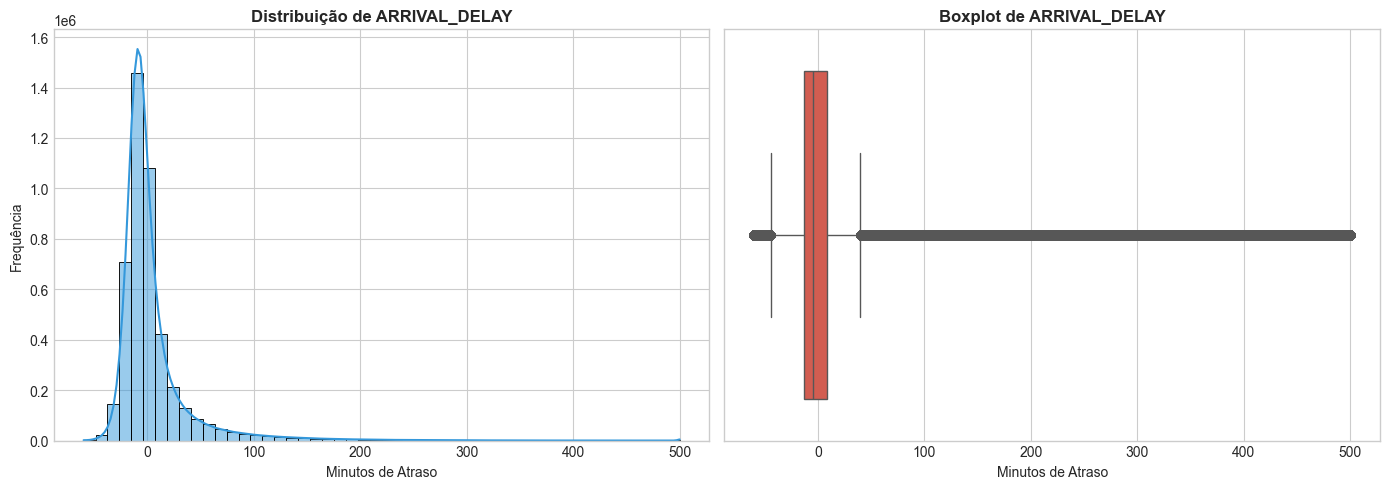

Estatísticas Descritivas Traning Target:
count   4571206.0000
mean          4.3235
std          37.6508
min         -60.0000
25%         -13.0000
50%          -5.0000
75%           8.0000
max         500.0000
Name: ARRIVAL_DELAY_CLIPPED, dtype: float64


In [3]:
# =============================================================================
# DISTRIBUIÇÃO DO TARGET
# =============================================================================
if 'y_train' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma normal
    sns.histplot(y_train, bins=50, kde=True, ax=axes[0], color=COLORS[0])
    axes[0].set_title('Distribuição de ARRIVAL_DELAY', fontweight='bold')
    axes[0].set_xlabel('Minutos de Atraso')
    axes[0].set_ylabel('Frequência')

    # Boxplot
    sns.boxplot(x=y_train, ax=axes[1], color=COLORS[1])
    axes[1].set_title('Boxplot de ARRIVAL_DELAY', fontweight='bold')
    axes[1].set_xlabel('Minutos de Atraso')

    plt.tight_layout()
    os.makedirs('../data/processed', exist_ok=True)
    plt.savefig('../data/processed/fig_reg_01_target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Estatísticas Descritivas Traning Target:')
    print(y_train.describe())


---
## 4. Modelos Base e Comparação

Vamos treinar um baseline (`DummyRegressor`), regressão linear e modelos em ensemble. Utilizaremos uma função auxiliar para processar e registrar o desempenho de cada modelo.


In [4]:
# =============================================================================
# FUNÇÃO DE AVALIAÇÃO DE MODELOS
# =============================================================================
def evaluate_regressor(model, name, X_train, y_train, X_test, y_test, results_dict=None):
    """
    Treina e avalia um modelo de regressão.
    Retorna dicionário de métricas e salva no results_dict, se fornecido.
    """
    print(f'\n🚀 Treinando {name}...')
    model.fit(X_train, y_train)
    
    # Previsões
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    # Calculando Métricas GERAIS Teste
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    
    # Train stats for overfitting check
    r2_train = r2_score(y_train, y_pred_train)
    
    print(f'✅ Concluído!')
    print(f'   - R² (Train): {r2_train:.4f}')
    print(f'   - R² (Test) : {r2:.4f}')
    print(f'   - RMSE      : {rmse:.4f}')
    print(f'   - MAE       : {mae:.4f}')
    
    metrics = {
        'Model': name,
        'R2_Train': r2_train,
        'R2_Test': r2,
        'RMSE': rmse,
        'MAE': mae
    }
    
    if results_dict is not None:
        results_dict[name] = metrics
        
    return metrics, model


---
## 4.1 Treinando os Modelos Base


In [5]:
# =============================================================================
# TREINAMENTO DOS MODELOS
# =============================================================================
if 'X_train' in locals():
    results = {}
    models_dict = {}

    # 1. Dummy Regressor (Baseline)
    dummy = DummyRegressor(strategy='mean')
    _, models_dict['Dummy'] = evaluate_regressor(dummy, 'Dummy', X_train, y_train, X_test, y_test, results)

    # 2. Linear Regression (Scaled)
    linear_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    _, models_dict['Linear Regression'] = evaluate_regressor(linear_pipeline, 'Linear Regression', X_train, y_train, X_test, y_test, results)

    # 3. Random Forest (limitando depth/trees para treinar rápido)
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
    _, models_dict['Random Forest'] = evaluate_regressor(rf, 'Random Forest', X_train, y_train, X_test, y_test, results)

    # 4. XGBoost
    if XGB_AVAILABLE:
        xgb_reg = xgb.XGBRegressor(
            n_estimators=200, 
            max_depth=6, 
            learning_rate=0.1, 
            random_state=RANDOM_STATE,
            **XGB_DEVICE_PARAMS
        )
        _, models_dict['XGBoost'] = evaluate_regressor(xgb_reg, 'XGBoost', X_train, y_train, X_test, y_test, results)

    # 5. LightGBM (opcional se quiser comparar com rápido Gradient Boosting)
    if LGBM_AVAILABLE:
        lgb_reg = lgb.LGBMRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        _, models_dict['LightGBM'] = evaluate_regressor(lgb_reg, 'LightGBM', X_train, y_train, X_test, y_test, results)



🚀 Treinando Dummy...
✅ Concluído!
   - R² (Train): 0.0000
   - R² (Test) : -0.0000
   - RMSE      : 37.6756
   - MAE       : 21.1384

🚀 Treinando Linear Regression...
✅ Concluído!
   - R² (Train): 0.9324
   - R² (Test) : 0.9325
   - RMSE      : 9.7904
   - MAE       : 6.9031

🚀 Treinando Random Forest...
✅ Concluído!
   - R² (Train): 0.9244
   - R² (Test) : 0.9240
   - RMSE      : 10.3864
   - MAE       : 7.5109

🚀 Treinando XGBoost...
✅ Concluído!
   - R² (Train): 0.9304
   - R² (Test) : 0.9294
   - RMSE      : 10.0132
   - MAE       : 6.6019

🚀 Treinando LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.070041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1843
[LightGBM] [Info] Number of data points in the train set: 4571206, number of used features: 30
[LightGBM] [Info] Start training from score 4.323454
✅ Concluído!
   

---
## 5. Comparação de Modelos

Vamos comparar as métricas (`R²`, `RMSE`, `MAE`) de todos os modelos avaliados para identificar o mais promissor.


,Model,R2_Train,R2_Test,RMSE,MAE
4,LightGBM,0.9400,0.9399,9.2390,6.4397
1,Linear Regression,0.9324,0.9325,9.7904,6.9031
3,XGBoost,0.9304,0.9294,10.0132,6.6019
2,Random Forest,0.9244,0.9240,10.3864,7.5109
0,Dummy,0.0000,-0.0000,37.6756,21.1384


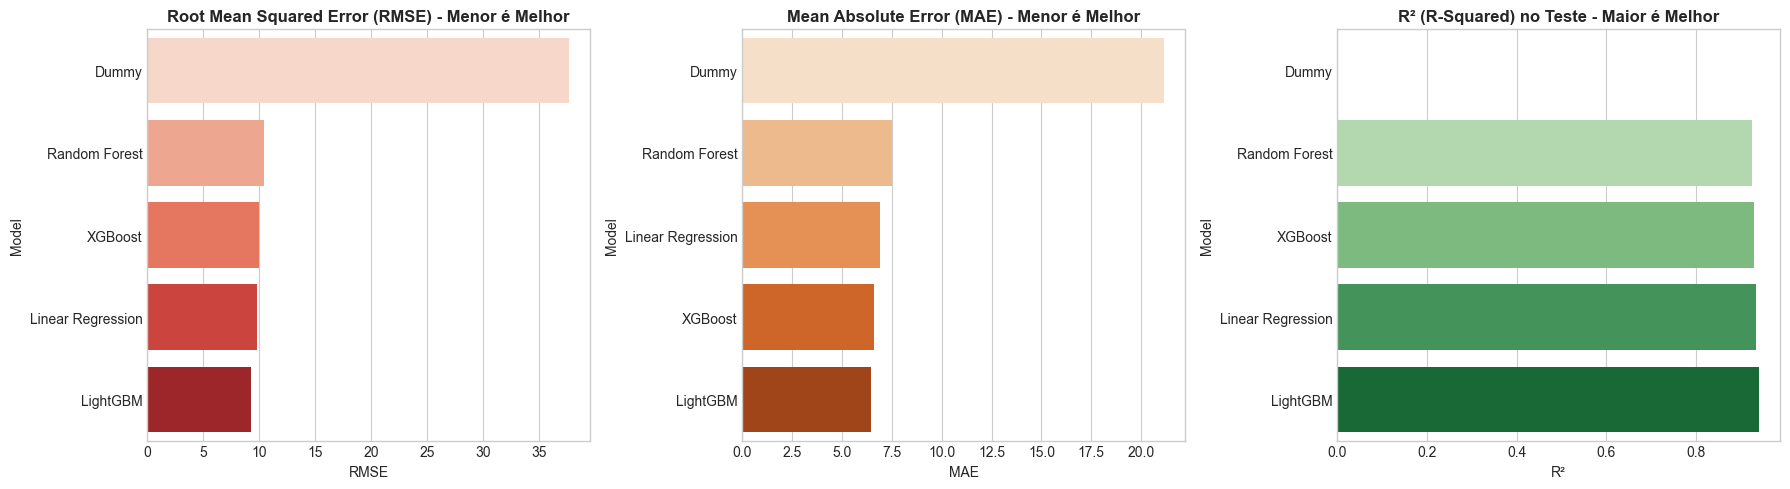

In [6]:
# =============================================================================
# COMPARAÇÃO VISUAL
# =============================================================================
if 'results' in locals() and len(results) > 0:
    results_df = pd.DataFrame.from_dict(results, orient='index').reset_index(drop=True)
    display(results_df.sort_values(by='RMSE'))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # RMSE Plot
    sns.barplot(data=results_df.sort_values('RMSE', ascending=False), x='RMSE', y='Model', ax=axes[0], palette='Reds')
    axes[0].set_title('Root Mean Squared Error (RMSE) - Menor é Melhor', fontweight='bold')
    axes[0].set_xlabel('RMSE')

    # MAE Plot
    sns.barplot(data=results_df.sort_values('MAE', ascending=False), x='MAE', y='Model', ax=axes[1], palette='Oranges')
    axes[1].set_title('Mean Absolute Error (MAE) - Menor é Melhor', fontweight='bold')
    axes[1].set_xlabel('MAE')

    # R² Plot
    sns.barplot(data=results_df.sort_values('R2_Test'), x='R2_Test', y='Model', ax=axes[2], palette='Greens')
    axes[2].set_title('R² (R-Squared) no Teste - Maior é Melhor', fontweight='bold')
    axes[2].set_xlabel('R²')

    plt.tight_layout()
    plt.savefig('../data/processed/fig_reg_02_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## 6. Tuning do Melhor Modelo

Aplicamos `RandomizedSearchCV` no melhor modelo base (menor RMSE, excluindo baseline) para buscar uma combinação de hiperparâmetros com melhor generalização.


In [7]:
# =============================================================================
# RANDOMIZED SEARCH CV — MELHOR MODELO BASE
# =============================================================================
if 'results_df' in locals() and len(results_df) > 1:
    # Exclui baseline dummy da seleção do melhor candidato para tuning
    candidate_df = results_df[results_df['Model'] != 'Dummy'].copy()
    best_base_model_name = candidate_df.loc[candidate_df['RMSE'].idxmin(), 'Model']
    print(f'🔍 Melhor modelo base para tuning: {best_base_model_name}')

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    if best_base_model_name == 'Random Forest':
        base_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
        param_dist = {
            'n_estimators': [200, 400, 600],
            'max_depth': [None, 8, 12, 16, 24],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', 0.5, 0.8]
        }
        n_iter = 30

    elif best_base_model_name == 'XGBoost' and XGB_AVAILABLE:
        base_model = xgb.XGBRegressor(
            random_state=RANDOM_STATE,
            **XGB_DEVICE_PARAMS
        )
        param_dist = {
            'n_estimators': [200, 400, 600],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.02, 0.1, 0.28],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'min_child_weight': [1, 5, 10],
            'reg_alpha': uniform(0.0, 1.0),
            'reg_lambda': uniform(0.5, 2.5)
        }
        n_iter = 25

    elif best_base_model_name == 'LightGBM' and LGBM_AVAILABLE:
        base_model = lgb.LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        param_dist = {
            'n_estimators': [200, 400, 600],
            'max_depth': [-1, 6, 8, 12, 16],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [20, 40, 60, 80],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.4, 0.6, 0.8],
            'min_child_samples': [20, 40, 60],
            'reg_alpha': [0.0, 0.5, 1.0],
            'reg_lambda': [0.5, 1.0, 2.0]
        }
        n_iter = 25

    else:
        # Fallback para modelos lineares
        best_base_model_name = 'Ridge'
        base_model = Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge(random_state=RANDOM_STATE))
        ])
        param_dist = {
            'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 20.0]
        }
        n_iter = 30
        print('ℹ️  Aplicando fallback de tuning com Ridge Regression.')

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=1
    )

    print('🚀 Iniciando RandomizedSearchCV...')
    search.fit(X_train, y_train)

    tuned_name = f'{best_base_model_name} (Tuned)'
    print(f'✅ Melhor RMSE CV (neg): {search.best_score_:.4f}')
    print(f'✅ Melhores parâmetros: {search.best_params_}')

    # Avalia no test set e adiciona ao benchmark
    _, tuned_model = evaluate_regressor(
        search.best_estimator_, tuned_name, X_train, y_train, X_test, y_test, results
    )
    models_dict[tuned_name] = tuned_model

    # Atualiza tabela de comparação com o modelo tunado
    results_df = pd.DataFrame.from_dict(results, orient='index').reset_index(drop=True)
    print('\n📊 Comparação atualizada com modelo tunado:')
    display(results_df.sort_values(by='RMSE'))


🔍 Melhor modelo base para tuning: LightGBM
🚀 Iniciando RandomizedSearchCV...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1849
[LightGBM] [Info] Number of data points in the train set: 3656964, number of used features: 30
[LightGBM] [Info] Start training from score 4.312673
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1843
[LightGBM] [Info] Number of data points in the train set: 3656965, number of used features: 30
[LightGBM] [Info] Start training from score 4.322594
[LightGBM] [Info] Auto-choosing row-wise mult

,Model,R2_Train,R2_Test,RMSE,MAE
5,LightGBM (Tuned),0.9475,0.9467,8.6994,6.0215
4,LightGBM,0.9400,0.9399,9.2390,6.4397
1,Linear Regression,0.9324,0.9325,9.7904,6.9031
3,XGBoost,0.9304,0.9294,10.0132,6.6019
2,Random Forest,0.9244,0.9240,10.3864,7.5109
0,Dummy,0.0000,-0.0000,37.6756,21.1384


---
## 7. Avaliação Geral dos Resíduos do Melhor Modelo

A visualização de Valores Preditos vs. Valores Reais e a distribuição dos resíduos é essencial para validação de Regressões.


🏆 Melhor modelo selecionado: LightGBM (Tuned)


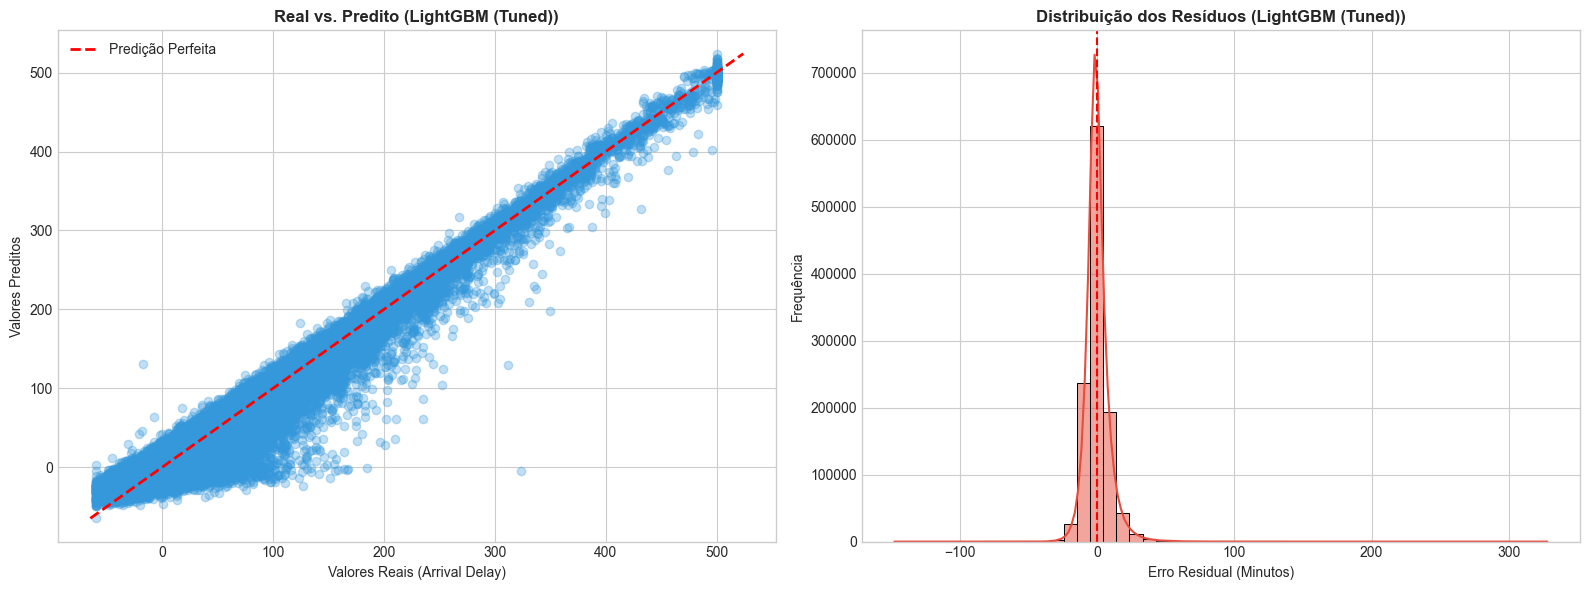

In [8]:
# =============================================================================
# ANÁLISE DE RESÍDUOS (MELHOR MODELO)
# =============================================================================
if 'results_df' in locals():
    # Definir o melhor modelo baseado no menor RMSE
    best_model_name = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
    print(f'🏆 Melhor modelo selecionado: {best_model_name}')

    best_model = models_dict[best_model_name]
    y_pred_best = best_model.predict(X_test)
    residuals = y_test - y_pred_best

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Real vs. Predito
    axes[0].scatter(y_test, y_pred_best, alpha=0.3, color=COLORS[0])
    # Linha ideal (y = x)
    max_val = max(y_test.max(), y_pred_best.max())
    min_val = min(y_test.min(), y_pred_best.min())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predição Perfeita')

    axes[0].set_title(f'Real vs. Predito ({best_model_name})', fontweight='bold')
    axes[0].set_xlabel('Valores Reais (Arrival Delay)')
    axes[0].set_ylabel('Valores Preditos')
    axes[0].legend()

    # Distribuição dos Resíduos
    sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color=COLORS[1])
    axes[1].axvline(x=0, color='r', linestyle='--')
    axes[1].set_title(f'Distribuição dos Resíduos ({best_model_name})', fontweight='bold')
    axes[1].set_xlabel('Erro Residual (Minutos)')
    axes[1].set_ylabel('Frequência')

    plt.tight_layout()
    plt.savefig('../data/processed/fig_reg_03_residuals.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## 8. Importância de Features

Verificando quais features mais influenciam o tempo de atraso.


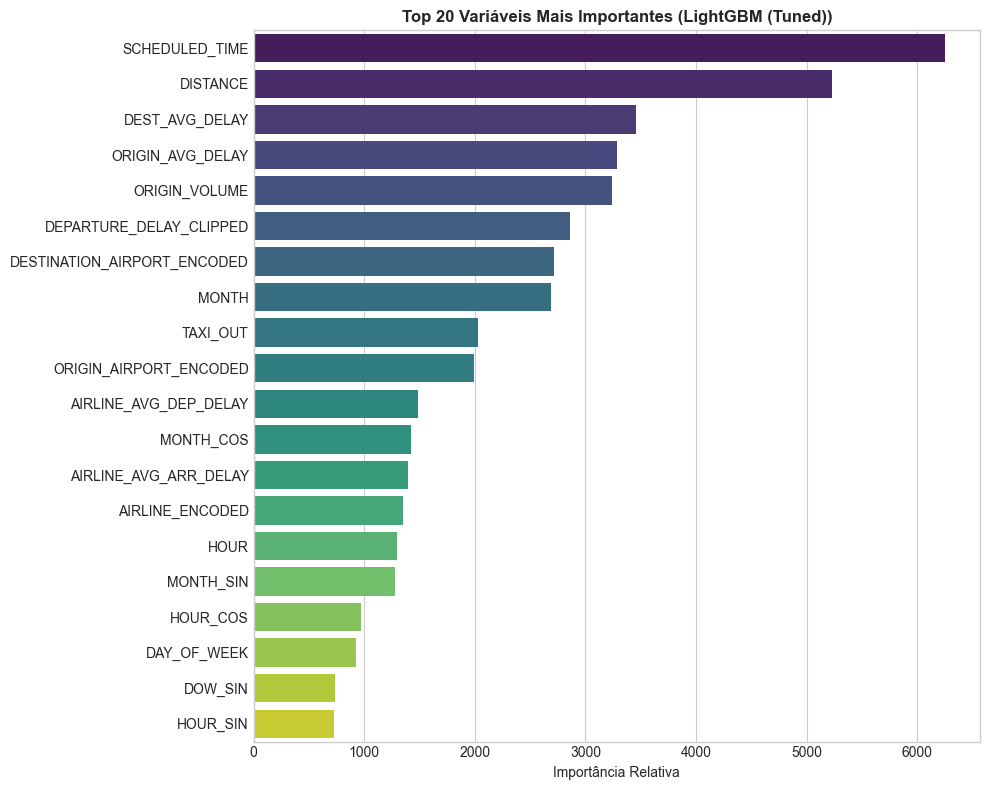

In [9]:
# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================
def plot_feature_importance(model, feature_names, top_n=15, best_model_name="Model"):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'named_steps') and hasattr(model.named_steps.get('lr'), 'coef_'):
        importances = np.abs(model.named_steps['lr'].coef_)
    else:
        print("⚠️ O modelo não possui atributo 'feature_importances_' direto.")
        return
    
    # Criar dataframe
    feat_impl_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_impl_df, palette='viridis')
    plt.title(f'Top {top_n} Variáveis Mais Importantes ({best_model_name})', fontweight='bold', fontsize=12)
    plt.xlabel('Importância Relativa')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig('../data/processed/fig_reg_04_feature_importance.png', dpi=150)
    plt.show()

if 'best_model' in locals():
    # Plota as importâncias do melhor modelo
    plot_feature_importance(best_model, features, top_n=20, best_model_name=best_model_name)


---
## 9. Salvamento do Modelo e Resultados

Salvando o melhor regressor e suas métricas para uso posterior ou deployment.


In [10]:
# =============================================================================
# SALVAMENTO
# =============================================================================
if 'best_model' in locals():
    model_path = '../models/supervised/regressor_final.joblib'
    metrics_path = '../models/supervised/regressor_metrics.joblib'
    metadata_path = '../models/supervised/regressor_metadata.joblib'

    os.makedirs('../models/supervised/', exist_ok=True)
    
    # Salva o melhor modelo
    joblib.dump(best_model, model_path)

    # Salva as métricas de todos os modelos
    joblib.dump(results, metrics_path)

    # Recupera métricas do melhor modelo no test set
    best_metrics = results.get(best_model_name, {})

    # Metadados no mesmo padrão do notebook de classificação
    reg_metadata = {
        'model_name': best_model_name,
        'features': features,
        'target_regression': target,
        'best_params': search.best_params_ if 'search' in locals() else None,
        'cv_rmse_neg': search.best_score_ if 'search' in locals() else None,
        'test_metrics': {
            'r2_train': best_metrics.get('R2_Train'),
            'r2_test': best_metrics.get('R2_Test'),
            'rmse': best_metrics.get('RMSE'),
            'mae': best_metrics.get('MAE')
        },
        'random_state': RANDOM_STATE
    }
    joblib.dump(reg_metadata, metadata_path)

    print(f'✅ Melhor modelo ({best_model_name}) salvo em: {model_path}')
    print(f'✅ Métricas salvas em: {metrics_path}')
    print(f'✅ Metadados salvos em: {metadata_path}')


✅ Melhor modelo (LightGBM (Tuned)) salvo em: ../models/supervised/regressor_final.joblib
✅ Métricas salvas em: ../models/supervised/regressor_metrics.joblib
✅ Metadados salvos em: ../models/supervised/regressor_metadata.joblib


---
## 10. Resumo Final

Consolidamos os principais resultados da modelagem de regressão e os artefatos salvos para uso posterior.


In [11]:
# =============================================================================
# RESUMO DO NOTEBOOK
# =============================================================================
if 'best_model' in locals() and 'results' in locals():
    print('📊 RESUMO — MODELAGEM DE REGRESSÃO')
    print('=' * 65)

    print(f'\n🔹 DADOS UTILIZADOS:')
    print(f'   Train: {len(X_train):,} registros | Test: {len(X_test):,} registros')
    print(f'   Features: {len(features)}')
    print(f'   Target: {target}')

    print(f'\n🔹 MODELOS TREINADOS:')
    for model_name, metric in results.items():
        print(
            f"   {model_name:<25} RMSE={metric['RMSE']:.4f}  "
            f"MAE={metric['MAE']:.4f}  R²={metric['R2_Test']:.4f}"
        )

    best_metrics = results.get(best_model_name, {})
    print(f'\n🏆 MELHOR MODELO FINAL: {best_model_name}')
    print(f"   R² (Train): {best_metrics.get('R2_Train', np.nan):.4f}")
    print(f"   R² (Test) : {best_metrics.get('R2_Test', np.nan):.4f}")
    print(f"   RMSE      : {best_metrics.get('RMSE', np.nan):.4f}")
    print(f"   MAE       : {best_metrics.get('MAE', np.nan):.4f}")

    if 'search' in locals():
        print(f'\n🔹 TUNING:')
        print(f'   Melhor score CV (neg RMSE): {search.best_score_:.4f}')
        print(f'   Melhores parâmetros: {search.best_params_}')

    print(f'\n🔹 ARTEFATOS SALVOS:')
    print('   📁 models/supervised/regressor_final.joblib')
    print('   📁 models/supervised/regressor_metrics.joblib')
    print('   📁 models/supervised/regressor_metadata.joblib')

    print('\n' + '=' * 65)
    print('🎯 PRÓXIMO PASSO: 05_clustering_analysis.ipynb')
    print('=' * 65)
else:
    print('⚠️ Execute as etapas de treino antes de gerar o resumo final.')


📊 RESUMO — MODELAGEM DE REGRESSÃO

🔹 DADOS UTILIZADOS:
   Train: 4,571,206 registros | Test: 1,142,802 registros
   Features: 30
   Target: ARRIVAL_DELAY_CLIPPED

🔹 MODELOS TREINADOS:
   Dummy                     RMSE=37.6756  MAE=21.1384  R²=-0.0000
   Linear Regression         RMSE=9.7904  MAE=6.9031  R²=0.9325
   Random Forest             RMSE=10.3864  MAE=7.5109  R²=0.9240
   XGBoost                   RMSE=10.0132  MAE=6.6019  R²=0.9294
   LightGBM                  RMSE=9.2390  MAE=6.4397  R²=0.9399
   LightGBM (Tuned)          RMSE=8.6994  MAE=6.0215  R²=0.9467

🏆 MELHOR MODELO FINAL: LightGBM (Tuned)
   R² (Train): 0.9475
   R² (Test) : 0.9467
   RMSE      : 8.6994
   MAE       : 6.0215

🔹 TUNING:
   Melhor score CV (neg RMSE): -8.7171
   Melhores parâmetros: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'num_leaves': 80, 'n_estimators': 600, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

🔹 ARTEFATOS SALVOS:
   📁 models/supervi